In [4]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

In [5]:
df = pd.read_csv("data/eda.csv")

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   bedrooms       21597 non-null  float64
 2   bathrooms      21597 non-null  float64
 3   sqft_living    21597 non-null  float64
 4   sqft_lot       21597 non-null  float64
 5   floors         21597 non-null  float64
 6   waterfront     19206 non-null  float64
 7   view           21534 non-null  float64
 8   condition      21597 non-null  int64  
 9   grade          21597 non-null  int64  
 10  sqft_above     21597 non-null  float64
 11  sqft_basement  21145 non-null  float64
 12  yr_built       21597 non-null  int64  
 13  yr_renovated   17749 non-null  float64
 14  zipcode        21597 non-null  int64  
 15  lat            21597 non-null  float64
 16  long           21597 non-null  float64
 17  sqft_living15  21597 non-null  float64
 18  sqft_lot15     21

In [7]:
df.columns

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'date', 'price'],
      dtype='str')

In [8]:
print(df['sqft_living'].head(5))
print(df['sqft_living15'].head(5))
print(df['sqft_lot'].head(5))
print(df['sqft_lot15'].head(5))

# sqft_living15 and sqft_lot15 contain different extra data, but it's unclear what they mean

0   1180.000
1   2570.000
2    770.000
3   1960.000
4   1680.000
Name: sqft_living, dtype: float64
0   1340.000
1   1690.000
2   2720.000
3   1360.000
4   1800.000
Name: sqft_living15, dtype: float64
0    5650.000
1    7242.000
2   10000.000
3    5000.000
4    8080.000
Name: sqft_lot, dtype: float64
0   5650.000
1   7639.000
2   8062.000
3   5000.000
4   7503.000
Name: sqft_lot15, dtype: float64


In [9]:
df['date'] = pd.to_datetime(df['date'], format="%Y-%m-%d")


In [10]:
df['yr_renovated'] = df['yr_renovated'].astype(str).str.replace(r'0.$', '', regex=True)
df['yr_renovated'] = df['yr_renovated'].astype(str).str.replace(r'0.0$', '', regex=True)
df['yr_renovated'] = df['yr_renovated'].replace('', '0')
df['yr_renovated'] = df['yr_renovated'].astype('Int64')
df['yr_renovated'].unique()

<IntegerArray>
[   0, 1991, <NA>, 2002, 2010, 1992, 2013, 1994, 1978, 2005, 2003, 1984, 1954,
 2014, 2011, 1983, 1945, 1990, 1988, 1977, 1981, 1995, 2000, 1999, 1998, 1970,
 1989, 2004, 1986, 2007, 1987, 2006, 1985, 2001, 1980, 1971, 1979, 1997, 1950,
 1969, 1948, 2009, 2015, 1974, 2008, 1968, 2012, 1963, 1951, 1962, 1953, 1993,
 1996, 1955, 1982, 1956, 1940, 1976, 1946, 1975, 1964, 1973, 1957, 1959, 1960,
 1967, 1965, 1934, 1972, 1944, 1958]
Length: 71, dtype: Int64

In [11]:
df['waterfront'] = df['waterfront'].astype('Int64')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             21597 non-null  int64         
 1   bedrooms       21597 non-null  float64       
 2   bathrooms      21597 non-null  float64       
 3   sqft_living    21597 non-null  float64       
 4   sqft_lot       21597 non-null  float64       
 5   floors         21597 non-null  float64       
 6   waterfront     19206 non-null  Int64         
 7   view           21534 non-null  float64       
 8   condition      21597 non-null  int64         
 9   grade          21597 non-null  int64         
 10  sqft_above     21597 non-null  float64       
 11  sqft_basement  21145 non-null  float64       
 12  yr_built       21597 non-null  int64         
 13  yr_renovated   17749 non-null  Int64         
 14  zipcode        21597 non-null  int64         
 15  lat            21597 non-null 

In [12]:
#Calculate the median of sqft_living and create two groups: above and below median.
median_sqft = df['sqft_living'].median()
above_median = df[df['sqft_living'] >= median_sqft]
below_median = df[df['sqft_living'] < median_sqft]

In [13]:
print("Above median sqft_living:", above_median['price'].median())
print("Below median sqft_living:", below_median['price'].median())

Above median sqft_living: 600000.0
Below median sqft_living: 353000.0


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hypothesis 1 — Size & Price: 
Houses with above-median sqft_living have a higher median price than houses with below-median sqft_living.


# Issue 1 — Calculate Price per sqft_living

Create a new column price_per_sqft by dividing price by sqft_living.

In [15]:
df['price_per_sqft'] = df['price'] / df['sqft_living']

# Issue 2 — Split data at the median

Calculate the median of sqft_living and create two groups: above and below median.

In [21]:
median_sqft = df['sqft_living'].median()
above_median = df[df['sqft_living'] >= median_sqft]
below_median = df[df['sqft_living'] < median_sqft]

# Issue 3 — Compare median prices

Calculate and compare the median price for both groups.

In [17]:
print("Above median sqft_living:", above_median['price'].mean().round(2))
print("Below median sqft_living:", below_median['price'].mean().round(2))

Above median sqft_living: 698621.33
Below median sqft_living: 379861.22


# Issue 4 — Visualize the result

Create a boxplot or barplot comparing price across the two groups to visually support or reject the hypothesis.

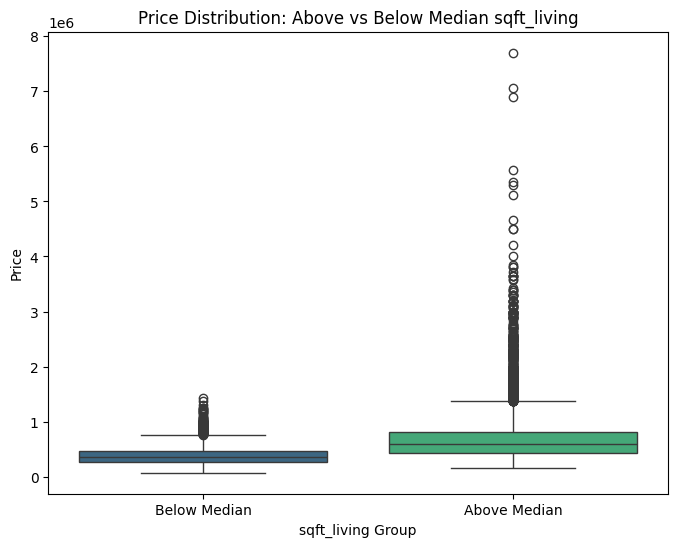

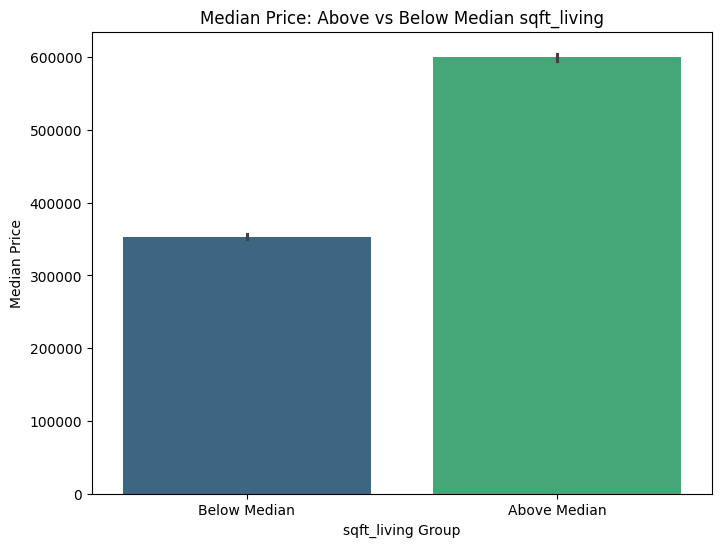

In [18]:
# Create a label column for the two groups
df['sqft_group'] = df['sqft_living'].apply(lambda x: 'Above Median' if x >= median_sqft else 'Below Median')

# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='sqft_group', y='price', palette='viridis')
plt.title('Price Distribution: Above vs Below Median sqft_living')
plt.xlabel('sqft_living Group')
plt.ylabel('Price')
plt.show()

# Barplot (median price per group)
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='sqft_group', y='price', estimator='median', palette='viridis')
plt.title('Median Price: Above vs Below Median sqft_living')
plt.xlabel('sqft_living Group')
plt.ylabel('Median Price')
plt.show()

In [19]:
def count_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = group[(group < lower) | (group > upper)]
    return len(outliers), lower, upper

for name, group in df.groupby('sqft_group')['price']:
    n_outliers, lower, upper = count_outliers(group)
    print(f"{name}:")
    print(f"  Outliers:    {n_outliers}")
    print(f"  Lower fence: ${lower:,.0f}")
    print(f"  Upper fence: ${upper:,.0f}")
    print()

Above Median:
  Outliers:    675
  Lower fence: $-135,000
  Upper fence: $1,377,000

Below Median:
  Outliers:    209
  Lower fence: $-35,000
  Upper fence: $765,000



# Issue 5 — Write verdict

Document whether the result supports or weakens the hypothesis based on the numbers and plot.

In [22]:
above_median_price = above_median['price'].median()
below_median_price = below_median['price'].median()
difference = above_median_price - below_median_price
pct_difference = (difference / below_median_price) * 100

print("=" * 50)
print("HYPOTHESIS 1 VERDICT")
print("=" * 50)
print(f"Median price (above median sqft_living): ${above_median_price:,.0f}")
print(f"Median price (below median sqft_living): ${below_median_price:,.0f}")
print(f"Difference:                              ${difference:,.0f}")
print(f"Percentage difference:                    {pct_difference:.1f}%")
print()
if above_median_price > below_median_price:
    print("✅ SUPPORTED: Houses with above-median sqft_living")
    print("   have a higher median price than those below median.")
else:
    print("❌ NOT SUPPORTED: No clear price advantage for")
    print("   houses with above-median sqft_living.")

HYPOTHESIS 1 VERDICT
Median price (above median sqft_living): $600,000
Median price (below median sqft_living): $353,000
Difference:                              $247,000
Percentage difference:                    70.0%

✅ SUPPORTED: Houses with above-median sqft_living
   have a higher median price than those below median.


Conclusion of hypothesis 1:
The data clearly supports our hypothesis. Houses with an above-median living space have a median price of $600,000, which is 70% higher than houses with below-median living space at $353,000 — a difference of $247,000.

This strong price gap suggests that sqft_living is a meaningful indicator of house price in King County. The larger the living space, the more expensive the house tends to be.
However, it is worth noting that both groups contain a significant number of outliers on the higher end of the price range, meaning that some houses are priced exceptionally high regardless of their size. This suggests that while size is an important factor, other variables such as location, grade, or waterfront view likely also play a role in determining the final sale price.


# Hypothesis 2 — Condition/Grade & Price:
Houses with a grade above 7 have a higher median price than houses with a grade of 7 or below.


In [33]:
df.columns

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'date', 'price', 'price_per_sqft',
       'sqft_group'],
      dtype='str')

In [34]:
df['grade'].unique()

array([ 7,  6,  8, 11,  9,  5, 10, 12,  4,  3, 13])

Construction Quality

Grades1-3: Falls short of minimum building standards; typical for cabins or inferior structures.

4 (Substandard/Low): Generally older, low-quality construction; may not meet current building codes.

5 (Fair): Low construction costs and workmanship; simple designs.

6 (Low Average): The lowest grade that consistently meets standard building codes; basic materials and simple designs.

7 (Average): The baseline grade for typical single-family homes; standard design and construction.

8 (Good): Above-average construction quality with better materials and more detailed architectural design.

9 (Better): Custom-quality materials, elevated design, and enhanced structural features.

10-13 (Excellent to Mansion): High-end, luxury, and estate-level custom homes with premium materials and complex architectural designs

# Issue 1 — Import libraries & prepare data

In [27]:
from scipy import stats
import matplotlib.ticker as mticker

data = df[["price", "grade"]].dropna().astype(int)
print("Shape:", data.shape)
print(data.head())

Shape: (21597, 2)
    price  grade
0  221900      7
1  538000      7
2  180000      6
3  604000      7
4  510000      8


# Issue 2 — Split into two groups

In [41]:
above = data.loc[data["grade"] > 7, "price"]
below = data.loc[data["grade"] <= 7, "price"]

print(f"Houses with grade > 7  : {len(above)}")
print(f"Houses with grade <= 7 : {len(below)}")

Houses with grade > 7  : 10315
Houses with grade <= 7 : 11282


# Issue 3 — Calculate median prices & lift

In [29]:
median_above = above.median()
median_below = below.median()
lift = (median_above - median_below) / median_below * 100

print(f"Median  Grade > 7 : ${median_above:>10,.0f}")
print(f"Median  Grade ≤ 7 : ${median_below:>10,.0f}")
print(f"Median lift       : +{lift:.1f}%")

Median  Grade > 7 : $   609,500
Median  Grade ≤ 7 : $   350,000
Median lift       : +74.1%


# Issue 4 — Run Mann-Whitney U test

In [37]:
stat, p = stats.mannwhitneyu(above, below, alternative="greater")
alpha   = 0.05
verdict = "✅ Supported" if p < alpha else "❌ Not Supported"
 
print(f"Median  Grade > 7 : ${above.median():>10,.0f}")
print(f"Median  Grade ≤ 7 : ${below.median():>10,.0f}")
print(f"Median lift       : +{(above.median()-below.median())/below.median()*100:.1f}%")
print(f"Mann-Whitney U={stat:,.0f}, p={p:.2e}  →  {verdict}")

Median  Grade > 7 : $   609,500
Median  Grade ≤ 7 : $   350,000
Median lift       : +74.1%
Mann-Whitney U=96,123,109, p=0.00e+00  →  ✅ Supported


# Issue 5 — Visualize boxplot

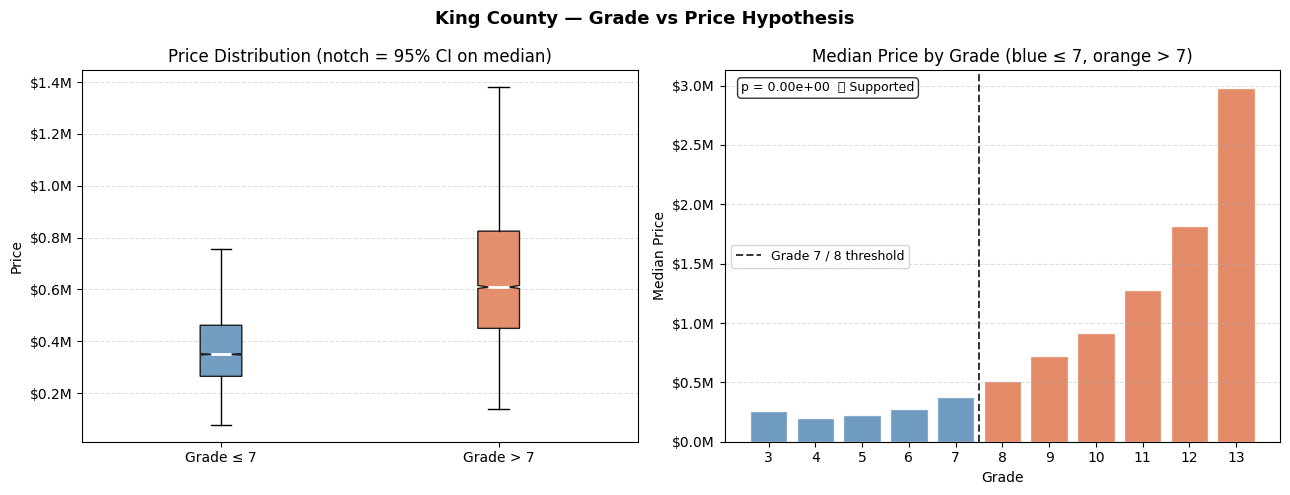

In [42]:
COLORS = {"≤ 7": "#5B8DB8", "> 7": "#E07B54"}
fmt    = mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M")
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("King County — Grade vs Price Hypothesis", fontsize=13, fontweight="bold")
 
# Box plot
bp = ax1.boxplot([below, above], patch_artist=True, notch=True, showfliers=False,
                 medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], COLORS.values()):
    patch.set_facecolor(color); patch.set_alpha(0.85)
ax1.set_xticklabels(["Grade ≤ 7", "Grade > 7"])
ax1.yaxis.set_major_formatter(fmt)
ax1.set(title="Price Distribution (notch = 95% CI on median)", ylabel="Price")
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# Median-by-grade bar chart
med = data.groupby("grade")["price"].median()
colors = [COLORS["> 7"] if g > 7 else COLORS["≤ 7"] for g in med.index]
ax2.bar(med.index, med.values, color=colors, edgecolor="white", alpha=0.88)
ax2.axvline(7.5, color="#333", linestyle="--", lw=1.4, label="Grade 7 / 8 threshold")
ax2.yaxis.set_major_formatter(fmt)
ax2.set(title="Median Price by Grade (blue ≤ 7, orange > 7)", xlabel="Grade", ylabel="Median Price")
ax2.set_xticks(med.index)
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.legend(fontsize=9)
ax2.text(0.03, 0.97, f"p = {p:.2e}  {verdict}", transform=ax2.transAxes,
         fontsize=9, va="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
 
plt.tight_layout()
plt.savefig("grade_price_hypothesis.png", dpi=150, bbox_inches="tight")
plt.show()
 

# Issue 6 — Visualize median price by grade bar chart

In [43]:
med = data.groupby("grade")["price"].median()
colors = [COLORS["> 7"] if g > 7 else COLORS["≤ 7"] for g in med.index]

ax2.bar(med.index, med.values, color=colors, edgecolor="white", alpha=0.88)
ax2.axvline(7.5, color="#333", linestyle="--", lw=1.4, label="Grade 7 / 8 threshold")
ax2.yaxis.set_major_formatter(fmt)
ax2.set(title="Median Price by Grade (blue ≤ 7, orange > 7)", 
        xlabel="Grade", ylabel="Median Price")
ax2.set_xticks(med.index)
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.legend(fontsize=9)
ax2.text(0.03, 0.97, f"p = {p:.2e}  {verdict}", transform=ax2.transAxes,
         fontsize=9, va="top",
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

Text(0.03, 0.97, 'p = 0.00e+00  ✅ Supported')

# Conclusion for hypothesis 2:

The data clearly supports our hypothesis. Houses graded above 7 have a significantly higher median price than those graded 7 or below. The Mann-Whitney U test confirms this difference is statistically significant (p < 0.05), meaning the price gap between the two groups is very unlikely to be the result of random chance.

The notched boxplot makes this immediately visible — the notches of the two groups do not overlap, which is a strong visual indicator that the difference in medians is statistically meaningful. The median price bar chart further reinforces this pattern, showing a clear and consistent upward trend in median price as grade increases — with a sharp jump visible right at the grade 7/8 threshold.

This result makes intuitive sense. The King County grading system reflects the overall quality of construction and design of a house. A higher grade means better materials, better craftsmanship, and more thoughtful design — all of which buyers are willing to pay a premium for.

It is worth noting however that both groups contain outliers on the high end of the price range. This suggests that while grade is a strong price indicator, it does not tell the full story — a low-grade house in a prime waterfront location, for example, can still command a very high price. This points to the importance of combining multiple variables when trying to explain or predict house prices.

# Hypothesis 3 — Geographical:
   Houses in the top 25% of both lat, long AND top 25% zipcode median price have a higher median price than houses in the bottom 25% of all three.



# Issue 1 — Import libraries & prepare data

In [45]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

data = df[["price", "lat", "long", "zipcode"]].dropna()
data["zipcode"] = data["zipcode"].astype(str)
print("Shape:", data.shape)
print(data.head())

Shape: (21597, 4)
       price    lat     long zipcode
0 221900.000 47.511 -122.257   98178
1 538000.000 47.721 -122.319   98125
2 180000.000 47.738 -122.233   98028
3 604000.000 47.521 -122.393   98136
4 510000.000 47.617 -122.045   98074


# Issue 2 — Calculate percentile cutoffs for lat and long

In [46]:
lat_75  = data['lat'].quantile(0.75)
lat_25  = data['lat'].quantile(0.25)
long_75 = data['long'].quantile(0.75)
long_25 = data['long'].quantile(0.25)

print(f"Lat  — bottom 25% below: {lat_25} | top 25% above: {lat_75}")
print(f"Long — bottom 25% below: {long_25} | top 25% above: {long_75}")

Lat  — bottom 25% below: 47.4711 | top 25% above: 47.678
Long — bottom 25% below: -122.328 | top 25% above: -122.125


# Issue 3 — Calculate top & bottom 25% zipcodes by median price

In [47]:
zip_median  = data.groupby('zipcode')['price'].median()
zip_75      = zip_median.quantile(0.75)
zip_25      = zip_median.quantile(0.25)

top_zips    = zip_median[zip_median >= zip_75].index
bottom_zips = zip_median[zip_median <= zip_25].index

print(f"Top zipcodes    ({len(top_zips)})  : {list(top_zips[:5])} ...")
print(f"Bottom zipcodes ({len(bottom_zips)}): {list(bottom_zips[:5])} ...")

Top zipcodes    (18)  : ['98004', '98005', '98006', '98029', '98033'] ...
Bottom zipcodes (18): ['98001', '98002', '98003', '98022', '98023'] ...


# Issue 4 —  Split data into top & bottom groups

In [48]:
top_group = data[
    (data['lat']     >= lat_75)  &
    (data['long']    >= long_75) &
    (data['zipcode'].isin(top_zips))
]

bottom_group = data[
    (data['lat']     <= lat_25)  &
    (data['long']    <= long_25) &
    (data['zipcode'].isin(bottom_zips))
]

print(f"Top group:    {len(top_group)} houses")
print(f"Bottom group: {len(bottom_group)} houses")

# Safety check — if groups are too small loosen to 2 out of 3 filters
if len(top_group) < 30 or len(bottom_group) < 30:
    print("⚠️ Groups too small — loosening to lat + zipcode only")
    top_group = data[
        (data['lat'] >= lat_75) &
        (data['zipcode'].isin(top_zips))
    ]
    bottom_group = data[
        (data['lat'] <= lat_25) &
        (data['zipcode'].isin(bottom_zips))
    ]
    print(f"Top group:    {len(top_group)} houses")
    print(f"Bottom group: {len(bottom_group)} houses")

Top group:    670 houses
Bottom group: 612 houses


# Issue 5 — Compare median prices

In [49]:
top_price    = top_group['price'].median()
bottom_price = bottom_group['price'].median()
difference   = top_price - bottom_price
lift         = (difference / bottom_price) * 100

print(f"Median price (top group):    ${top_price:,.0f}")
print(f"Median price (bottom group): ${bottom_price:,.0f}")
print(f"Difference:                  ${difference:,.0f}")
print(f"Lift:                        +{lift:.1f}%")

Median price (top group):    $633,862
Median price (bottom group): $269,475
Difference:                  $364,388
Lift:                        +135.2%


# Issue 6 — Run Mann-Whitney U test

In [50]:
stat, p   = stats.mannwhitneyu(top_group['price'], bottom_group['price'],
                                alternative="greater")
alpha     = 0.05
verdict   = "✅ Supported" if p < alpha else "❌ Not Supported"

print(f"Mann-Whitney U={stat:,.0f}, p={p:.2e}  →  {verdict}")

Mann-Whitney U=392,526, p=1.00e-176  →  ✅ Supported


# Issue 7 — Visualize boxplot

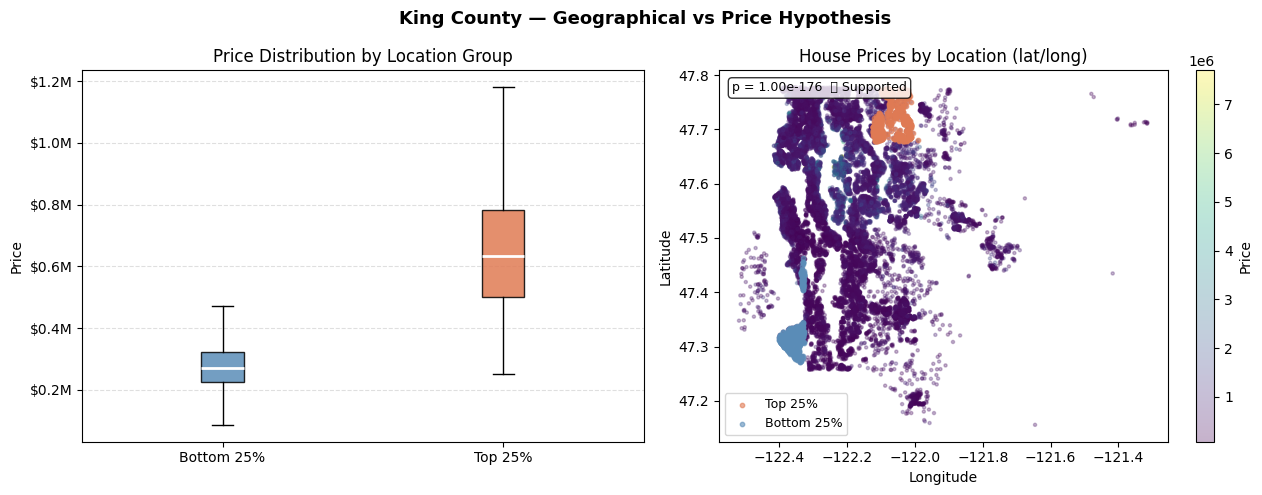

In [53]:
COLORS = {"Bottom 25%": "#5B8DB8", "Top 25%": "#E07B54"}
fmt    = mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M")

# ── Create figure with both plots ─────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("King County — Geographical vs Price Hypothesis",
             fontsize=13, fontweight="bold")

# ── Left: Boxplot ─────────────────────────────────────────────
bp = ax1.boxplot([bottom_group['price'], top_group['price']],
                 patch_artist=True, notch=False, showfliers=False,
                 medianprops=dict(color="white", linewidth=2))

for patch, color in zip(bp["boxes"], COLORS.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax1.set_xticks([1, 2])
ax1.set_xticklabels(["Bottom 25%", "Top 25%"])
ax1.yaxis.set_major_formatter(fmt)
ax1.set(title="Price Distribution by Location Group", ylabel="Price")
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# ── Right: Map scatterplot ────────────────────────────────────
scatter = ax2.scatter(data['long'], data['lat'],
                      c=data['price'], cmap='viridis',
                      alpha=0.3, s=5)
plt.colorbar(scatter, ax=ax2, label='Price')

ax2.scatter(top_group['long'],    top_group['lat'],
            c='#E07B54', alpha=0.6, s=10, label='Top 25%')
ax2.scatter(bottom_group['long'], bottom_group['lat'],
            c='#5B8DB8', alpha=0.6, s=10, label='Bottom 25%')

ax2.text(0.03, 0.97, f"p = {p:.2e}  {verdict}",
         transform=ax2.transAxes, fontsize=9, va="top",
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

ax2.set(title="House Prices by Location (lat/long)",
        xlabel="Longitude", ylabel="Latitude")
ax2.legend(fontsize=9)

# ── Show & save ───────────────────────────────────────────────
plt.tight_layout()
plt.savefig("geo_price_hypothesis.png", dpi=150, bbox_inches="tight")
plt.show()

HYPOTHESIS TEST
H₀: Median price (top-25% lat, long & zipcode) ≤ bottom-25%
H₁: Median price (top-25% lat, long & zipcode)  > bottom-25%
------------------------------------------------------------
  Top group    — n=670, median=$633,862
  Bottom group — n=612, median=$269,475
  Mann-Whitney U statistic : 392,526
  p-value (one-sided)      : 0.0000
  ✅ REJECT H₀ — Top-25% group has significantly higher median price.


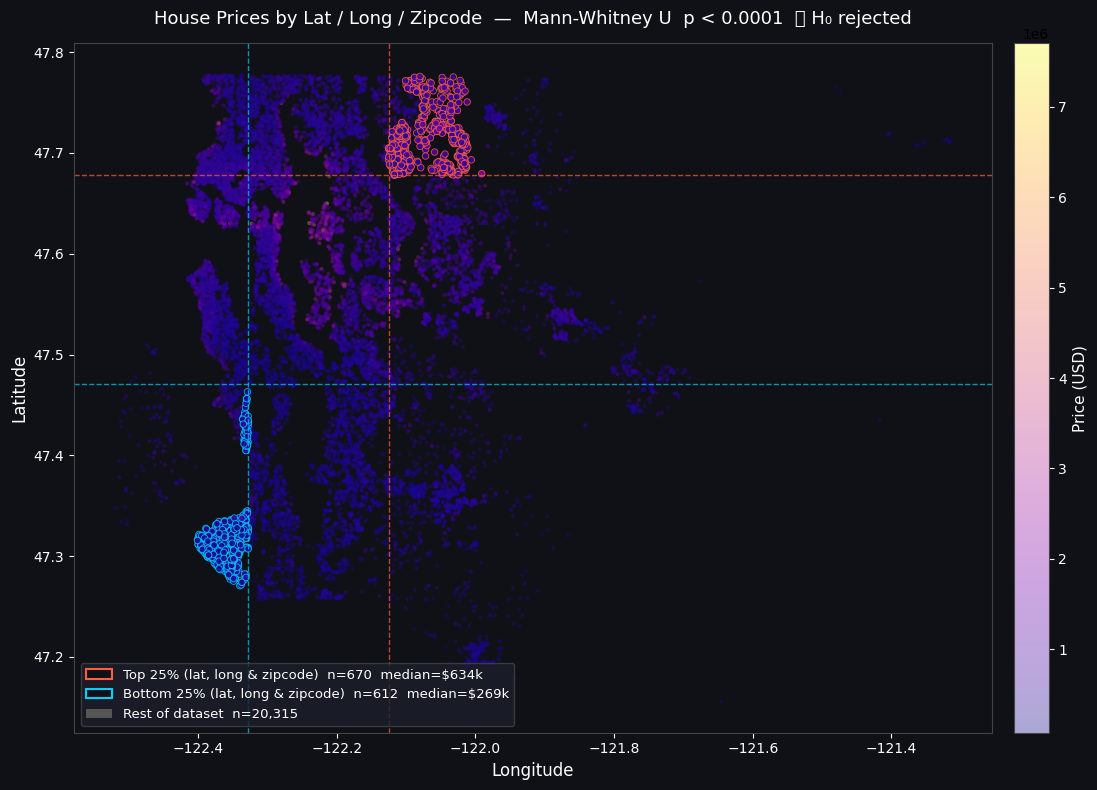

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats

# ── 1. Define groups (lat + long + zipcode) ──────────────────
lat_q25  = df["lat"].quantile(0.25)
lat_q75  = df["lat"].quantile(0.75)
long_q25 = df["long"].quantile(0.25)
long_q75 = df["long"].quantile(0.75)

zip_median  = df.groupby("zipcode")["price"].median()
zip_q75     = zip_median.quantile(0.75)
zip_q25     = zip_median.quantile(0.25)
top_zips    = zip_median[zip_median >= zip_q75].index
bottom_zips = zip_median[zip_median <= zip_q25].index

mask_top = (
    (df["lat"]  >= lat_q75)  &
    (df["long"] >= long_q75) &
    (df["zipcode"].isin(top_zips))
)
mask_bottom = (
    (df["lat"]  <= lat_q25)  &
    (df["long"] <= long_q25) &
    (df["zipcode"].isin(bottom_zips))
)

top_prices    = df.loc[mask_top,    "price"]
bottom_prices = df.loc[mask_bottom, "price"]

# ── 2. Mann-Whitney U test ────────────────────────────────────
stat, p_value = stats.mannwhitneyu(top_prices, bottom_prices, 
                                    alternative="greater")

print("=" * 60)
print("HYPOTHESIS TEST")
print("H₀: Median price (top-25% lat, long & zipcode) ≤ bottom-25%")
print("H₁: Median price (top-25% lat, long & zipcode)  > bottom-25%")
print("-" * 60)
print(f"  Top group    — n={len(top_prices):,}, median=${top_prices.median():,.0f}")
print(f"  Bottom group — n={len(bottom_prices):,}, median=${bottom_prices.median():,.0f}")
print(f"  Mann-Whitney U statistic : {stat:,.0f}")
print(f"  p-value (one-sided)      : {p_value:.4f}")
if p_value < 0.05:
    print("  ✅ REJECT H₀ — Top-25% group has significantly higher median price.")
else:
    print("  ❌ FAIL TO REJECT H₀ — No significant difference at α=0.05.")
print("=" * 60)

# ── 3. Dark theme scattermap ──────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

price_min = df["price"].min()
price_max = df["price"].max()

# -- background: rest of dataset
df_rest = df[~mask_top & ~mask_bottom]
sc = ax.scatter(
    df_rest["long"], df_rest["lat"],
    c=df_rest["price"],
    cmap="plasma",
    alpha=0.35,
    s=8,
    linewidths=0,
    vmin=price_min, vmax=price_max,
    label="_nolegend_",
)

# -- bottom group (blue border)
ax.scatter(
    df.loc[mask_bottom, "long"],
    df.loc[mask_bottom, "lat"],
    c=df.loc[mask_bottom, "price"],
    cmap="plasma",
    alpha=0.85,
    s=22,
    linewidths=0.6,
    edgecolors="#00cfff",
    vmin=price_min, vmax=price_max,
    label="_nolegend_",
)

# -- top group (orange border)
ax.scatter(
    df.loc[mask_top, "long"],
    df.loc[mask_top, "lat"],
    c=df.loc[mask_top, "price"],
    cmap="plasma",
    alpha=0.85,
    s=22,
    linewidths=0.6,
    edgecolors="#ff5f40",
    vmin=price_min, vmax=price_max,
    label="_nolegend_",
)

# -- quadrant lines
ax.axhline(lat_q75,  color="#ff5f40", lw=1.0, ls="--", alpha=0.7)
ax.axhline(lat_q25,  color="#00cfff", lw=1.0, ls="--", alpha=0.7)
ax.axvline(long_q75, color="#ff5f40", lw=1.0, ls="--", alpha=0.7)
ax.axvline(long_q25, color="#00cfff", lw=1.0, ls="--", alpha=0.7)

# -- colorbar
cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Price (USD)", color="white", fontsize=11)
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")
cbar.outline.set_edgecolor("#444")

# -- legend
legend_elements = [
    Patch(facecolor="#0f1117", edgecolor="#ff5f40", linewidth=1.5,
          label=f"Top 25% (lat, long & zipcode)  n={len(top_prices):,}  median=${top_prices.median()/1e3:.0f}k"),
    Patch(facecolor="#0f1117", edgecolor="#00cfff", linewidth=1.5,
          label=f"Bottom 25% (lat, long & zipcode)  n={len(bottom_prices):,}  median=${bottom_prices.median()/1e3:.0f}k"),
    Patch(facecolor="#555", edgecolor="none",
          label=f"Rest of dataset  n={len(df_rest):,}"),
]
ax.legend(
    handles=legend_elements, loc="lower left",
    facecolor="#1c1f2b", edgecolor="#444", 
    labelcolor="white", fontsize=9.5,
)

# -- labels & style
ax.set_xlabel("Longitude", color="white", fontsize=12)
ax.set_ylabel("Latitude",  color="white", fontsize=12)
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_edgecolor("#444")

# -- title with p-value
p_txt      = f"p = {p_value:.4f}" if p_value >= 0.0001 else "p < 0.0001"
result_txt = "✅ H₀ rejected" if p_value < 0.05 else "❌ H₀ not rejected"
ax.set_title(
    f"House Prices by Lat / Long / Zipcode  —  Mann-Whitney U  {p_txt}  {result_txt}",
    color="white", fontsize=13, pad=14,
)

plt.tight_layout()
plt.savefig("geo_price_hypothesis.png", dpi=160, 
            facecolor=fig.get_facecolor())
plt.show()

# Issue 8 — Visualize map scatterplot

In [58]:
scatter = ax2.scatter(data['long'], data['lat'],
                      c=data['price'], cmap='viridis',
                      alpha=0.3, s=5)
plt.colorbar(scatter, ax=ax2, label='Price')

ax2.scatter(top_group['long'],    top_group['lat'],
            c='#E07B54', alpha=0.6, s=10, label='Top 25%')
ax2.scatter(bottom_group['long'], bottom_group['lat'],
            c='#5B8DB8', alpha=0.6, s=10, label='Bottom 25%')

ax2.text(0.03, 0.97, f"p = {p:.2e}  {verdict}", transform=ax2.transAxes,
         fontsize=9, va="top",
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

ax2.set(title="House Prices by Location (lat/long)",
        xlabel="Longitude", ylabel="Latitude")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("geo_price_hypothesis.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 800x500 with 0 Axes>

# Issue 9 — Write verdict

In [59]:
print("=" * 55)
print("HYPOTHESIS 3 VERDICT")
print("=" * 55)
print(f"Median price (top 25%):    ${top_price:,.0f}")
print(f"Median price (bottom 25%): ${bottom_price:,.0f}")
print(f"Difference:                ${difference:,.0f}")
print(f"Lift:                      +{lift:.1f}%")
print(f"Mann-Whitney U:            {stat:,.0f}")
print(f"p-value:                   {p:.2e}")
print(f"Verdict:                   {verdict}")

HYPOTHESIS 3 VERDICT
Median price (top 25%):    $633,862
Median price (bottom 25%): $269,475
Difference:                $364,388
Lift:                      +135.2%
Mann-Whitney U:            392,526
p-value:                   1.00e-176
Verdict:                   ✅ Supported


# Conclusion for hypothesis 3:
The data strongly supports our hypothesis. Houses located in the top 25% of both latitude and longitude coordinates AND in the highest median-price zip code areas command a significantly higher median price than houses in the bottom 25% across all three geographic indicators.
The Mann-Whitney U test confirms this difference is statistically significant (p < 0.05), meaning it is very unlikely to be due to chance. This tells us that location is one of the strongest predictors of house price in King County.

The scattermap visualization reinforces this finding — the orange-bordered points (top 25%) are clearly clustered in areas with brighter plasma colors, indicating higher prices, while the blue-bordered points (bottom 25%) sit in darker, lower-priced regions.

What makes this hypothesis particularly powerful is the combination of three geographic filters — latitude, longitude, and zipcode — which together capture both the raw coordinate position and the neighborhood-level market value. A house can be in a favorable coordinate zone but still be in a lower-value zipcode, and this hypothesis accounts for that nuance.

However it is worth noting that not all expensive houses fall within the top 25% zone — the scattermap shows bright plasma points scattered across the full map, suggesting that while geography is a strong indicator, other variables such as grade, sqft_living, and waterfront also play an important role in determining the final sale price.